# Composite Models and depending pars

In [1]:
import jetset
print("tested with",jetset.__version__)

tested with 1.4.0rc3


In [2]:
from jetset.model_manager import FitModel


## Combine a Jet model with the EBL model (Multiplicative case)

We start by combining a Jet model with the EBL absorption model, i.e. a multiplicative  model. First, we define our Jet model

In [3]:
from jetset.jet_model import Jet
my_jet=Jet(electron_distribution='lppl',name='jet_flaring')

In [4]:
from jetset.template_2Dmodel import EBLAbsorptionTemplate
ebl_franceschini=EBLAbsorptionTemplate.from_name('Franceschini_2008')

In [5]:
composite_model=FitModel(nu_size=500,name='EBL corrected')
composite_model.add_component(my_jet)
composite_model.add_component(ebl_franceschini)


/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/model_manager.py:259: UserWarning: no cosmology defined, using FlatLambdaCDM(name="Planck13", H0=67.77 km / (Mpc s), Om0=0.30712, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.048252)
  warnings.warn(m)


the waring message is just telling that you are not passing any specific cosmology model to the `FitModel` class, so it is using a default one

In [6]:
composite_model.show_pars()

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_flaring,R,region_size,cm,5.000000e+15,1.000000e+03,1.000000e+30,False,False
jet_flaring,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_flaring,B,magnetic_field,gauss,1.000000e-01,0.000000e+00,--,False,False
jet_flaring,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_flaring,beam_obj,beaming,,1.000000e+01,1.000000e-04,--,False,False
jet_flaring,z_cosm,redshift,,1.000000e-01,0.000000e+00,--,False,False
jet_flaring,gmin,low-energy-cut-off,lorentz-factor*,2.000000e+00,1.000000e+00,1.000000e+09,False,False
jet_flaring,gmax,high-energy-cut-off,lorentz-factor*,1.000000e+06,1.000000e+00,1.000000e+15,False,False
jet_flaring,N,emitters_density,1 / cm3,1.000000e+02,0.000000e+00,--,False,False
jet_flaring,gamma0_log_parab,turn-over-energy,lorentz-factor*,1.000000e+04,1.000000e+00,1.000000e+09,False,False


Since, both the Jet model the EBL share the same parameter, i.e. the redshift, we link the two parameters 

In [7]:
composite_model.link_par(par_name='z_cosm', from_model=my_jet.name, to_model='Franceschini_2008')


In [8]:
composite_model.show_pars()

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_flaring,R,region_size,cm,5.000000e+15,1.000000e+03,1.000000e+30,False,False
jet_flaring,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_flaring,B,magnetic_field,gauss,1.000000e-01,0.000000e+00,--,False,False
jet_flaring,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_flaring,beam_obj,beaming,,1.000000e+01,1.000000e-04,--,False,False
jet_flaring,"z_cosm(L,Franceschini_2008)",redshift,,--,--,--,False,True
jet_flaring,gmin,low-energy-cut-off,lorentz-factor*,2.000000e+00,1.000000e+00,1.000000e+09,False,False
jet_flaring,gmax,high-energy-cut-off,lorentz-factor*,1.000000e+06,1.000000e+00,1.000000e+15,False,False
jet_flaring,N,emitters_density,1 / cm3,1.000000e+02,0.000000e+00,--,False,False
jet_flaring,gamma0_log_parab,turn-over-energy,lorentz-factor*,1.000000e+04,1.000000e+00,1.000000e+09,False,False


As you can see, now the paramter `z_cosm` in `jet_flaring` is the `master` parameter (flagged by the M in parenthesis), and the one belonging to the `Franceschini_2008` component is the linked one (flagged by the L in parenthesis).

## Setting parameters

These methods are alternative and equivalent ways to set a parameter in a composite model:

a) accessing the model component member of the 

b) using `set_par` and passing as first argument the model component name

c) using `set_par` and passing as first argument the model component object

In [9]:
#a
composite_model.Franceschini_2008.parameters.z_cosm.val=0.1
#b
composite_model.set_par('Franceschini_2008','z_cosm',0.1)
#c
composite_model.set_par(ebl_franceschini,'z_cosm',0.1)

And now, we can define the functional form of the model composition, just by writing the mathematical expression as a string, using the model names reported in the model description table, and that's it!

In [10]:
composite_model.show_model_components()


--------------------------------------------------------------------------------
Composite model description
--------------------------------------------------------------------------------
name: EBL corrected  
type: composite_model  
components models:
 -model name: jet_flaring model type: jet
 -model name: Franceschini_2008 model type: table2D

--------------------------------------------------------------------------------


In [11]:
composite_model.composite_expr='jet_flaring*Franceschini_2008'

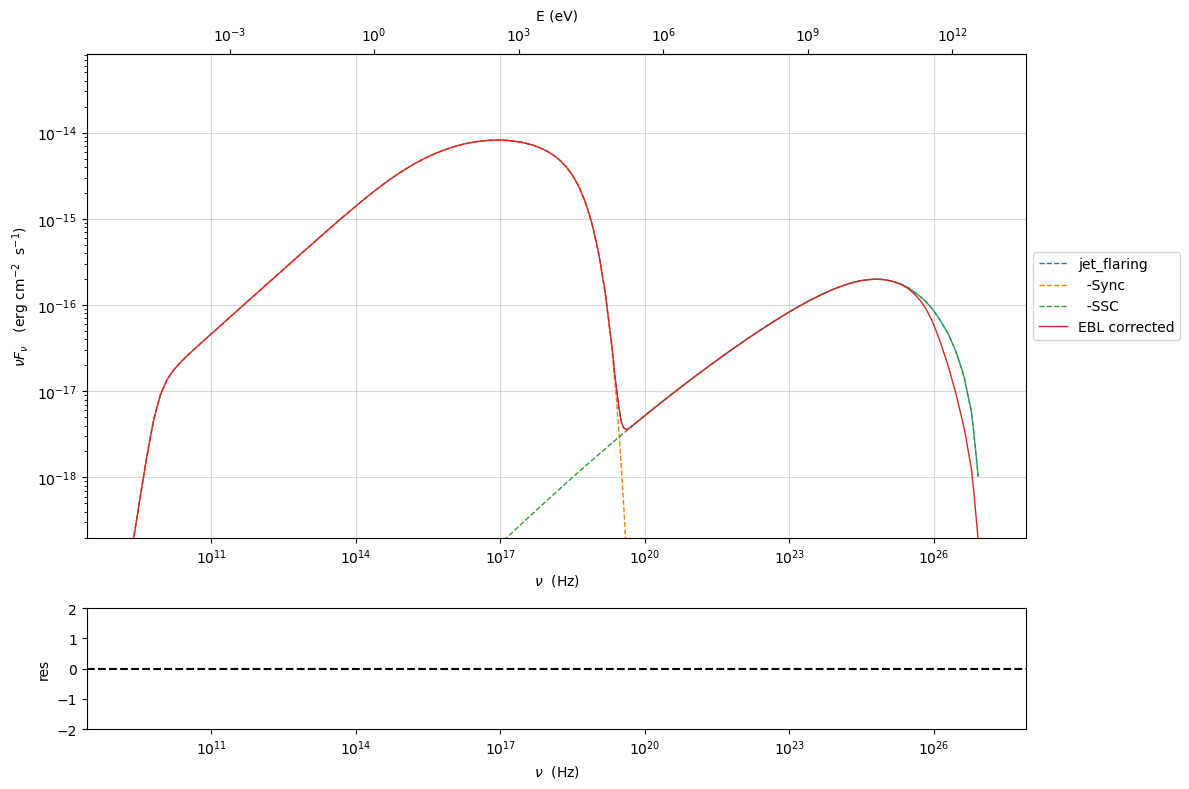

In [12]:
composite_model.jet_flaring.IC_nu_size=150
composite_model.eval()
p=composite_model.plot_model()


In [13]:
composite_model.save_model('composite.pkl')
cm=FitModel.load_model('composite.pkl')

## Sum of two jets (steady and flaring) and application of the EBL absorption to both (Multiplicative and additive)

Assume that now we want to sum to jet models (a steady and flaring component) and apply to both of them the EBL absorption.

In [14]:
composite_model=FitModel(nu_size=500,name='EBL corrected flaring+steady')
composite_model.add_component(my_jet)
composite_model.add_component(ebl_franceschini)

/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/model_manager.py:259: UserWarning: no cosmology defined, using FlatLambdaCDM(name="Planck13", H0=67.77 km / (Mpc s), Om0=0.30712, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.048252)
  warnings.warn(m)


In [15]:
steady_jet=Jet(electron_distribution='plc',name='steady_jet')
composite_model.add_component(steady_jet)
composite_model.show_model_components()


--------------------------------------------------------------------------------
Composite model description
--------------------------------------------------------------------------------
name: EBL corrected flaring+steady  
type: composite_model  
components models:
 -model name: jet_flaring model type: jet
 -model name: Franceschini_2008 model type: table2D
 -model name: steady_jet model type: jet

--------------------------------------------------------------------------------


now we link the same parameter `z_cosm` from the `steady_jet` to the same `master` parameter used for the `EBL` model, i.e. to the `jet_flaring` model

In [16]:
composite_model.link_par(par_name='z_cosm',from_model=['steady_jet'],to_model='Franceschini_2008') 

In [17]:
composite_model.show_pars()

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_flaring,R,region_size,cm,5.000000e+15,1.000000e+03,1.000000e+30,False,False
jet_flaring,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_flaring,B,magnetic_field,gauss,1.000000e-01,0.000000e+00,--,False,False
jet_flaring,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_flaring,beam_obj,beaming,,1.000000e+01,1.000000e-04,--,False,False
jet_flaring,"z_cosm(L,Franceschini_2008)",redshift,,--,--,--,False,True
jet_flaring,gmin,low-energy-cut-off,lorentz-factor*,2.000000e+00,1.000000e+00,1.000000e+09,False,False
jet_flaring,gmax,high-energy-cut-off,lorentz-factor*,1.000000e+06,1.000000e+00,1.000000e+15,False,False
jet_flaring,N,emitters_density,1 / cm3,1.000000e+02,0.000000e+00,--,False,False
jet_flaring,gamma0_log_parab,turn-over-energy,lorentz-factor*,1.000000e+04,1.000000e+00,1.000000e+09,False,False


In [18]:
composite_model.steady_jet.IC_nu_size=150


In [19]:
composite_model.composite_expr='(jet_flaring + steady_jet) * Franceschini_2008'

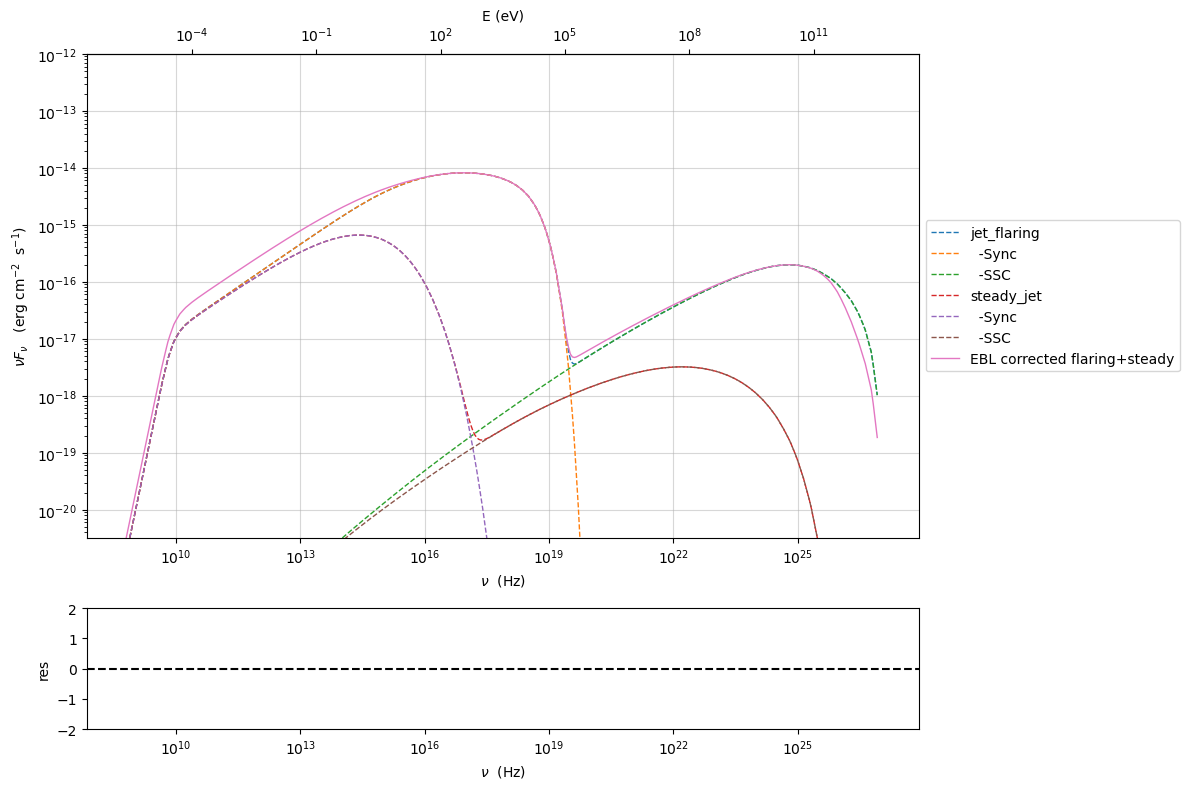

In [20]:
composite_model.eval()
p=composite_model.plot_model()
p.setlim(y_max=1E-12)

In [21]:
composite_model.save_model('composite.pkl')

In [22]:
cm=FitModel.load_model('composite.pkl')

/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/base_model.py:440: UserWarning: found master par without name
  warnings.warn('found master par without name')


In [23]:
cm.show_pars()

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_flaring,gmin,low-energy-cut-off,lorentz-factor*,2.000000e+00,1.000000e+00,1.000000e+09,False,False
jet_flaring,gmax,high-energy-cut-off,lorentz-factor*,1.000000e+06,1.000000e+00,1.000000e+15,False,False
jet_flaring,N,emitters_density,1 / cm3,1.000000e+02,0.000000e+00,--,False,False
jet_flaring,gamma0_log_parab,turn-over-energy,lorentz-factor*,1.000000e+04,1.000000e+00,1.000000e+09,False,False
jet_flaring,s,LE_spectral_slope,,2.000000e+00,-1.000000e+01,1.000000e+01,False,False
jet_flaring,r,spectral_curvature,,4.000000e-01,-1.500000e+01,1.500000e+01,False,False
jet_flaring,R,region_size,cm,5.000000e+15,1.000000e+03,1.000000e+30,False,False
jet_flaring,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_flaring,B,magnetic_field,gauss,1.000000e-01,0.000000e+00,--,False,False
jet_flaring,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
